Brynna Garden & Paige Toth

Final Project Part 2: Statistical Analysis Plan

In [54]:
#Importing packages 

import os 

import numpy as np 

import pandas as pd 

import scipy.stats as stats 

import statsmodels.formula.api as smf 

In [55]:
from pathlib import Path

#Objective 1: importing data

# Get current working directory
current_dir = Path(os.getcwd())
print("Current directory:", current_dir)


from pathlib import Path

data_dir = Path(r"C:\Users\paige\OneDrive\Documents\GitHub\BIOS-584\data")
for f in data_dir.iterdir():
    print(f.name)


masskill_path = current_dir / "data" / "mass_killing_offenders_public(in).csv"
print("CSV path:", masskill_path)


if not masskill_path.exists():
    raise FileNotFoundError(f"File not found: {masskill_path}")


try:
    masskill_df = pd.read_csv(masskill_path, encoding="utf-8", low_memory=False)
except UnicodeDecodeError:

    masskill_df = pd.read_csv(masskill_path, encoding="latin1", low_memory=False)

print(masskill_df.head())


Current directory: C:\Users\paige\OneDrive\Documents\GitHub\BIOS-584
.ipynb_checkpoints
App Search.py
features.csv
K114_001_BCI_FRT_Truncated_Data_0.5_6.mat
K114_001_BCI_TRN_Truncated_Data_0.5_6.mat
mass_killing_offenders_public(in).csv
my_arr2.npy
my_arr2.npz
my_arr2_comp.npz
my_arr2_delimiter_comma.txt
my_arr2_delimiter_space.txt
my_arr2_twice.npz
my_arr2_twice_comp.npz
PTSD dataset.xlsx
PTSD_data_dictionary.xlsx
Quiz4
swLDA_predict_BCI_001_TRN_test_seq_size_1_threshold_0.5.json
week_09_test_csv
working_example_data.txt
working_example_data_2.txt
CSV path: C:\Users\paige\OneDrive\Documents\GitHub\BIOS-584\data\mass_killing_offenders_public(in).csv
   incident_id  offender_id firstname middlename          lastname suffix  \
0            1            1      Raul        NaN  Segura-Rodriguez    NaN   
1            1            2    Arturo        NaN            Ibarra    NaN   
2            2            3   Stanley        NaN             Neace    NaN   
3            3            4       

In [56]:
#Objective 2: Summary Statistics for our Variables  

df = pd.DataFrame(masskill_df)  

#variable 1: race
df['race_grouped'] = df['race'].str.lower().map({
    'white': 'White',
    'black': 'Black',
    'hispanic': 'Hispanic'
}).fillna('Other')

#frequencies and proportions
race_frequency = df['race_grouped'].value_counts()
race_proportions = df['race_grouped'].value_counts(normalize=True)

print(race_frequency)
print(race_proportions)
print()
#generating sentence describing race distribution
def generate_distribution_sentence(frequencies, proportions):
    sentence_parts = []
    distribution_df = pd.concat([frequencies, proportions], axis=1, keys=['count', 'proportion'])

    for race, row in distribution_df.iterrows():
        count = row['count']
        proportion = row['proportion'] * 100
        part = f"{race} with {count} individuals ({proportion:.1f}%)"
        sentence_parts.append(part)

    if len(sentence_parts) > 1:
        last_part = sentence_parts.pop()
        sentence = ", ".join(sentence_parts) + f", and {last_part}."
    else:
        sentence = sentence_parts[0] + "."

    return f"The distribution of race shows the following breakdown: {sentence}"

distribution_sentence = generate_distribution_sentence(race_frequency, race_proportions)
print(distribution_sentence)
    
                          
#variable 2: age
#Recoding Age Variable to be categorical  
bins = [0, 19, 29, 39, 49, np.inf] 
labels = ['9-19', '20-29', '30-39', '40-49', '50 or above']  
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)  
print("\nAge Group Counts:")  
print(df['age_group'].value_counts())  
print("\nAge Group Proportions:")  
print(df['age_group'].value_counts(normalize=True)) 

mean_age = df['age'].mean()
median_age = df['age'].median()
min_age = df['age'].min()
max_age = df['age'].max()
std_dev_age = df['age'].std()

#generating sentence describing age distribution
age_summary = (
    f"The age of offenders ranges from {min_age} to {max_age} years old, "
    f"with a mean age of {mean_age:.1f}, standard deviation of {std_dev_age:.0f} and a median age of {median_age:.0f}."
)

final_age_summary = f"The distribution of age shows the following breakdown: {age_summary}"
print(final_age_summary)


#variable 3: sex
sex_frequency = df['sex'].value_counts()  
sex_proportions = df['sex'].value_counts(normalize=True)  
print(sex_frequency) 
print(sex_proportions) 
print() 

#generating sentence describing sex distribution
def generate_distribution_sentence_sex(frequencies, proportions):
    sentence_parts_sex = []
    distribution_df_sex = pd.concat([frequencies, proportions], axis=1, keys=['count', 'proportion'])

    for sex, row in distribution_df_sex.iterrows():
        count = row['count']
        proportion = row['proportion'] * 100
        part = f"{sex} with {count} individuals ({proportion:.1f}%)"
        sentence_parts_sex.append(part)

    if len(sentence_parts_sex) > 1:
        last_part = sentence_parts_sex.pop()
        sentence_sex = ", ".join(sentence_parts_sex) + f", and {last_part}."
    else:
        sentence_sex = sentence_parts_sex[0] + "."

    return f"The distribution of sex shows the following breakdown: {sentence_sex}"


distribution_sentence_sex = generate_distribution_sentence_sex(sex_frequency, sex_proportions)
print(distribution_sentence_sex)


#variable 4: outcome

#recoding outcome
def collapse_outcomes(x):
    if pd.isna(x):
        return 'Other'   # or choose another label for missing data

    x = str(x).lower().strip()

    if x in ['suicide', 'suicide awaiting trial']:
        return 'Suicide'

    if x in ['killed', 'died awaiting trial']:
        return 'Death (non-suicide)'

    if x in ['life sentence', 'life without parole', 'life with parole']:
        return 'Life sentence'

    if x == 'death sentence':
        return 'Death sentence'

    if x in ['prison sentence', 'sentenced as juvenile']:
        return 'Prison sentence'

    if x == 'convicted':
        return 'Convicted (non-prison)'

    if x in ['acquitted', 'charges dropped']:
        return 'Acquitted / Charges dropped'

    if x in ['arrested/pending trial', 'incompetent', 'legally insane']:
        return 'Pending / Pretrial'

    if x in ['unsolved', 'fugitive']:
        return 'Unsolved / Fugitive'

    return 'Other'

df['outcome_grouped'] = df['outcome'].apply(collapse_outcomes)

#frequencies and proportions
outcome_frequency = df['outcome_grouped'].value_counts()  
outcome_proportions = df['outcome_grouped'].value_counts(normalize=True)  
print(outcome_frequency) 
print(outcome_proportions) 
print() 

#generating sentence describing outcome distribution
def generate_distribution_sentence_outcome(frequencies, proportions):
    sentence_parts_outcome = []
    distribution_df_outcome = pd.concat([frequencies, proportions], axis=1, keys=['count', 'proportion'])

    for outcome, row in distribution_df_outcome.iterrows():
        count = row['count']
        proportion = row['proportion'] * 100
        part = f"{outcome} with {count} individuals ({proportion:.1f}%)"
        sentence_parts_outcome.append(part)

    if len(sentence_parts_outcome) > 1:
        last_part = sentence_parts_outcome.pop()
        sentence_outcome = ", ".join(sentence_parts_outcome) + f", and {last_part}."
    else:
        sentence_outcome = sentence_parts_outcome[0] + "."

    return f"The distribution of outcomes shows the following breakdown: {sentence_outcome}"


distribution_sentence_outcome = generate_distribution_sentence_outcome(outcome_frequency, outcome_proportions)
print(distribution_sentence_outcome)


#variable 5: criminal justice process
process_frequency = df['criminal_justice_process'].value_counts()
process_proportions = df['criminal_justice_process'].value_counts(normalize=True)
print(process_frequency)
print(process_proportions)
print()

def generate_distribution_sentence_crim_justice(frequencies, proportions=None):
    """
    frequencies: pd.Series of counts (index = category)
    proportions: optional pd.Series of normalized proportions (index = category).
                 if None, proportions will be computed from frequencies.
    """
    import pandas as pd

    if proportions is None:
        proportions = frequencies / frequencies.sum()

    distribution_df_crim_justice = pd.concat([frequencies, proportions], axis=1, keys=['count', 'proportion'])

    sentence_parts_crim_justice = []
    for category, row in distribution_df_crim_justice.iterrows():
        count = int(row['count'])
        proportion = row['proportion'] * 100
        part = f"{category} with {count} individuals ({proportion:.1f}%)"
        sentence_parts_crim_justice.append(part)

    if len(sentence_parts_crim_justice) == 0:
        sentence_crim_justice = "No observations."
    elif len(sentence_parts_crim_justice) == 1:
        sentence_crim_justice = sentence_parts_crim_justice[0] + "."
    else:
        last_part = sentence_parts_crim_justice.pop()
        sentence_crim_justice = ", ".join(sentence_parts_crim_justice) + f", and {last_part}."

    return f"The distribution of criminal justice outcomes shows the following breakdown: {sentence_crim_justice}"


distribution_sentence_outcome = generate_distribution_sentence_crim_justice(process_frequency, process_proportions)
print(distribution_sentence_outcome)



race_grouped
White    294
Other    260
Black    253
Name: count, dtype: int64
race_grouped
White    0.364312
Other    0.322181
Black    0.313507
Name: proportion, dtype: float64

The distribution of race shows the following breakdown: White with 294.0 individuals (36.4%), Other with 260.0 individuals (32.2%), and Black with 253.0 individuals (31.4%).

Age Group Counts:
age_group
20-29          282
30-39          224
40-49          142
50 or above     62
9-19            54
Name: count, dtype: int64

Age Group Proportions:
age_group
20-29          0.369110
30-39          0.293194
40-49          0.185864
50 or above    0.081152
9-19           0.070681
Name: proportion, dtype: float64
The distribution of age shows the following breakdown: The age of offenders ranges from 9.0 to 73.0 years old, with a mean age of 32.2, standard deviation of 11 and a median age of 30.
sex
Male      716
Female     53
Name: count, dtype: int64
sex
Male      0.931079
Female    0.068921
Name: proportion, dtype: 

Objective 2: Summary Statistics  

We will be using five variables in our analyses, including four categorical variables (race, sex, outcome, and criminal justice process) and one continuous variable (age). However, for the purpose of this study, age has been aggregated into categorical groups in the following manner: 9-19, 20-29, 30-39, 40-49, 50-59, 60-69, and 70-79 years old. 

The Mass Killings in America, 2006-Present Dataset includes 656 incidents of mass killings involving a total of 862 perpetrators. For the purpose of this study, all analyses will be completed on individual offenders, as opposed to events.  

The largest proportion of offenders identified as White (40.92%, n=295), followed by Black (35.09%, n=253). Smaller proportions identified as Hispanic/Latino (15.95%, n=115), Asian/Pacific Islander (5.83%, n=42), American Indian (1.94%, n=14), or other categories (0.28%, n=2). Race data was unavailable for several offenders (9.98%, n= 86). Age at the time of the offense ranged from 9 to 73 years old. The largest age group committing a mass killing were those aged 20-29 years old (36.91%, n=282), followed by those aged 30-39 years old (29.32%, n=224), and those aged 40-49 years old (18.59%, n=142). Smaller proportions were those aged 9-19 years old (7.07%, n=54), those aged 50-59 years old (5.76%, n=44), those aged 60-69 years old (2.09%, n=16), and those aged 70-79 years old (0.26%, n=2). The majority of offenders were Male (93.11%, n=716), and a small proportion of offenders were Female (6.89%, n=53).  

The distribution of where the offender is in the criminal justice process shows the following breakdown: Not Applicable (32.24%, n=234), Trial (26.2%, n=196), Plea (25.0%, n=187), Arrested/Pending Trial (14.2%, n=106), Incompetent (1.6%, n=12), Charges Dropped (1.6%, n=12), and Fugitive (0.3%, n=2).  

The most common outcome following the mass killing was Suicide (23.95%, n=193), followed by Life Sentence (14.39%, n=116), Life Without Parole (13.90%, n=112), Arrested/Pending Trial  (13.28%, n=107), and Prison Sentence (11.29%, n=91). Fewer offenders were classified as Killed (6.20%, n=50), Unresolved (4.84%, n=39), Death Sentence (3.97%, n=32), Charges Dropped (1.86%, n=15), Incompetent (1.86%, n=12), Convicted (1.36%, n=11), Life With Parole (0.99%, n=8), Acquitted (0.99%, n=8), Died Awaiting Trial (0.62%, n=5), Suicide Awaiting Trial (0.37%, n=3), Fugitive (0.25%, n=2), Sentenced as Juvenile (0.12%, n=1), and Legally Insane (0.12%, n=1).  

Objective 3: Statistical Analysis Plan  

The five variables of interest in this analysis of the Mass Killings in America 2006 to Present dataset are race, age, sex, outcome, and criminal justice process. The pandas, numpy, and os packages in Pycharm will be used to conduct statistical analyses and create graphs (see Objective 4: Graphs). Four of the five variables are categorical; as discussed above, the continuous variable age has also been aggregated into categorical groups. Univariate analysis for all variables will include examination of frequencies and proportions (see Objective 2: Summary Statistics). Descriptive statistics for all variables will be visualized using stacked bar charts.  

The first aim of the analysis is to determine the association between race and the offenders' criminal justice outcome (i.e. life sentence, life without parole, arrested, suicide, etc.) following a mass killing. A chi-square test will be used to determine if there is a significant relationship between race and criminal justice outcome. This will allow us to understand if certain races are more or less likely to result in specific criminal justice outcomes.  

The second aim of the analysis is to determine the association between race and where the offender is in the criminal justice process (i.e. trial, pleas, pending trial etc.) following a mass killing. A chi-square test will be used to determine if there is a significant relationship between race and where the offender is in the criminal justice process. This will allow us to understand if certain races are more or less likely to result in specific criminal justice processes. 

The third and final aim of the analysis is to determine the association between demographic variables (i.e., age and sex) and whether the offender died by suicide following a mass killing. A chi-square test will be used to determine if there is a significant relationship between the independent variables age and sex, and the dependent variable suicide. This will allow us to understand the impact of different demographics (age and sex) on whether the offender dies by suicide following the mass killing.  

All analyses will be performed using Jupyter Notebook (version Classic Notebook V6). 

Objective 4: Graphs  

To answer the three research questions, the team will use stacked bar graphs because all the variables of interest are categorical.  

Graph 1 will answer Research Question 1 by determining the potential association between race and the offenders' criminal justice outcome (i.e. life sentence, life without parole, arrested, suicide, etc.) following a mass killing. Each bar will represent the ratio of race by criminal justice outcome, allowing us to visualize potential trends and discrepancies.  

Graph 2 will address Research Question 2 by visualizing the potential relationship between race and where the offender is in the criminal justice process (i.e. trial, pleas, pending trial etc.) following a mass killing. Much like Graph 1, this will allow us to identify potential racial disparities based on one’s experience within the criminal justice system. 

Lastly, Graph 3 serves to address Research Question 3 by identifying the potential relationship between the independent variables age and sex, and the dependent outcome of suicide. This will allow us to visualize the potential association between select demographic variables and risk for suicide following perpetration of a mass killing. 

Part 3: Conduct Statistical Analyses

Chi-square statistic: 207.72165916385643
Degrees of freedom: 18
P-value: 2.8467513211025836e-34
Reject the null hypothesis; there is a significant association between race and criminal justice outcome in this sample.


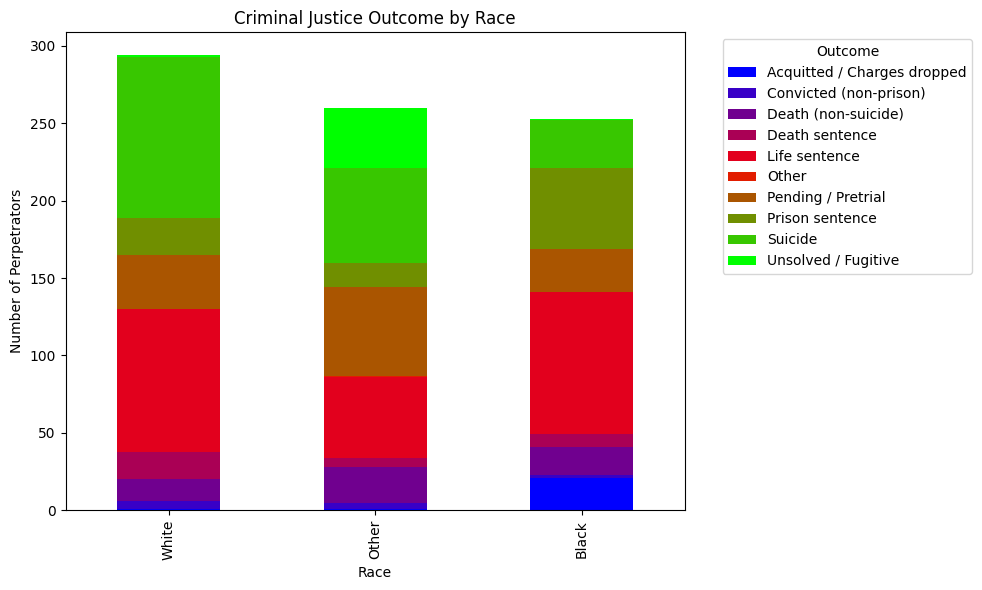

In [60]:
#aim 1: chi-square test for race and criminal justice outcome

#importing packages
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

observed_table_outcome = pd.crosstab(df['race_grouped'], df['outcome_grouped'])

#showing the table
observed_table_outcome

#chi-square test
chi2, p, dof, expected = chi2_contingency(observed_table_outcome)


#printing results
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

print("Reject the null hypothesis; there is a significant association between race and criminal justice outcome in this sample.")

#sorting race by descending total count for bar chart
observed_table_outcome['Total'] = observed_table_outcome.sum(axis=1)
observed_table_outcome = observed_table_outcome.sort_values('Total', ascending=False)
observed_table_outcome = observed_table_outcome.drop(columns='Total')
#creating stacked bar chartx

bar1 = observed_table_outcome.plot(kind='bar',
                                   stacked=True,
                                   figsize=(10,6),
                                   colormap='brg')

bar1.set_title('Criminal Justice Outcome by Race')
bar1.set_xlabel('Race')
bar1.set_ylabel('Number of Perpetrators')
bar1.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Chi-square statistic: 93.38116218919077
Degrees of freedom: 12
P-value: 1.0902070076698424e-14
Reject the null hypothesis; there is a significant correlation between race and where the offender is in the criminal justice process following a mass killing.


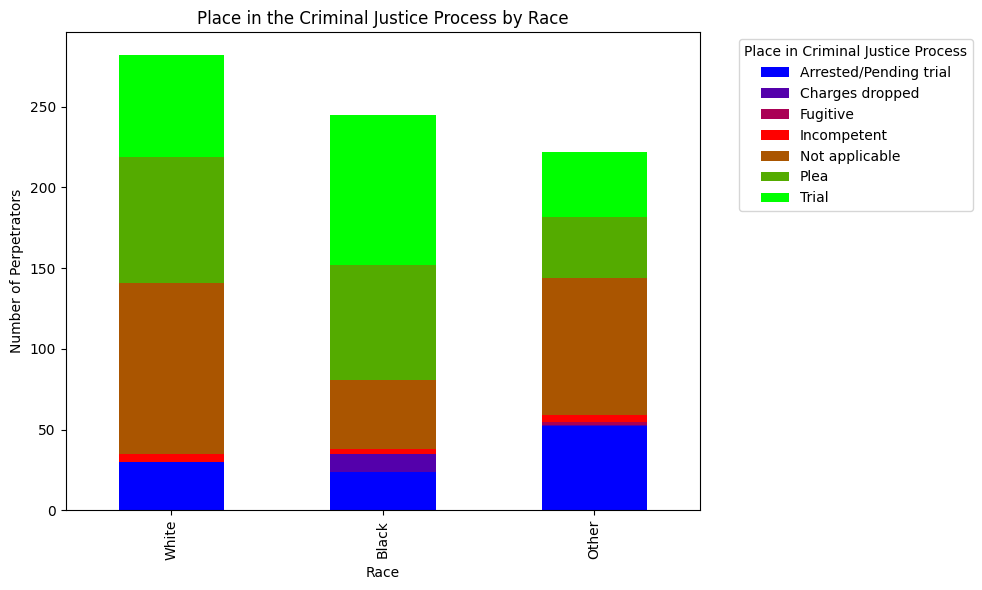

In [63]:
#aim 2: chi-square test for race and place in the criminal justice process (i.e., trial, plea, etc.)

observed_table_crim_process = pd.crosstab(df['race_grouped'], df['criminal_justice_process'])

#showing the table
observed_table_crim_process

#chi-square test
chi2, p, dof, expected = chi2_contingency(observed_table_crim_process)

#printing results
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)


print("Reject the null hypothesis; there is a significant correlation between race and where the offender is in the criminal justice process following a mass killing.")


#sorting criminal justice process by descending total count for bar chart
observed_table_crim_process['Total'] = observed_table_crim_process.sum(axis=1)
observed_table_crim_process = observed_table_crim_process.sort_values('Total', ascending=False)
observed_table_crim_process = observed_table_crim_process.drop(columns='Total')

#creating stacked bar chart

bar2 = observed_table_crim_process.plot(kind='bar',
                                   stacked=True,
                                   figsize=(10,6),
                                   colormap='brg')

bar2.set_title('Place in the Criminal Justice Process by Race')
bar2.set_xlabel('Race')
bar2.set_ylabel('Number of Perpetrators')
bar2.legend(title='Place in Criminal Justice Process', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Chi-square statistic: 82.86853775331552
Degrees of freedom: 9
P-value: 4.342791533465123e-14
Reject the null hypothesis; there is a significant correlation between age, sex, and the outcome of suicide in this sample.


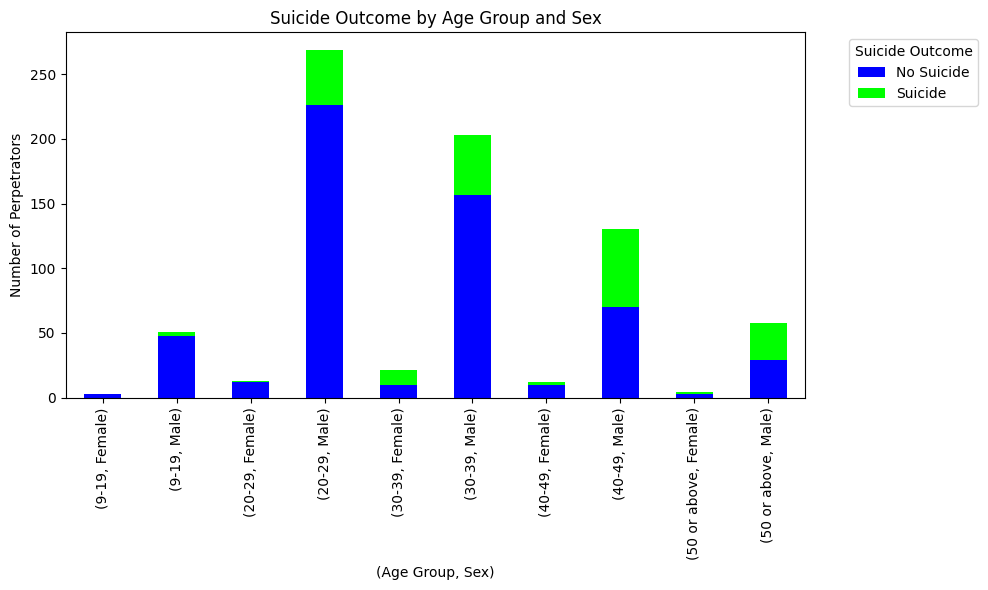

In [62]:
#aim 3: chi-square test for age, sex, and outcome of suicide

#creating a binary suicide variable
df['suicide'] = df['outcome_grouped'].apply(lambda x: 1 if x == 'Suicide' else 0)

observed_table_age_sex = pd.crosstab([df['age_group'], df['sex']], df['suicide'])

#showing the table
observed_table_age_sex

#chi-square test
chi2, p, dof, expected = chi2_contingency(observed_table_age_sex)

#printing results
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)


print("Reject the null hypothesis; there is a significant correlation between age, sex, and the outcome of suicide in this sample.")

#creating table suited for plotting
observed_table_age_sex_long = df.groupby(
    ['age_group', 'sex', 'suicide'],
    observed=True  
).size().reset_index(name='count')

#revert suicide from 0/1 to labeled values
observed_table_age_sex_long['suicide_label'] = observed_table_age_sex_long['suicide'].map({0: 'No Suicide', 1: 'Suicide'})

#pivoting the table for the stacked bar chart
pivot = observed_table_age_sex_long.pivot_table(
    index=['age_group', 'sex'],
    columns='suicide_label',
    values='count',
    fill_value=0,
    observed=True  
)
#creating stacked bar chart

bar3 = pivot.plot(kind='bar', stacked=True, figsize=(10,6), colormap='brg')

bar3.set_title('Suicide Outcome by Age Group and Sex')
bar3.set_xlabel('(Age Group, Sex)')
bar3.set_ylabel('Number of Perpetrators')
bar3.legend(title='Suicide Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


#TO-DO: check if Fisher's is more appropriate
